# CyberDash — XGBoost Model Training
## Objectif : Prédire P(succès) pour un couple (learner, challenge)

### Étapes :
1. Connexion à PostgreSQL et extraction des données
2. Feature Engineering (11 features)
3. Entraînement XGBoost
4. Évaluation (accuracy, AUC, confusion matrix)
5. Export du modèle en .pkl

In [ ]:
# Installer les dépendances si nécessaire
# !pip install xgboost scikit-learn pandas psycopg2-binary joblib matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import psycopg2
import psycopg2.extras
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIGURATION ===
DB_URL = {
    'host': 'localhost',
    'port': 5432,
    'dbname': 'cyberdash',      # Adaptez à votre nom de BDD
    'user': 'postgres',          # Adaptez
    'password': 'password'       # Adaptez
}

conn = psycopg2.connect(**DB_URL, cursor_factory=psycopg2.extras.RealDictCursor)
print('✅ Connecté à PostgreSQL')

✅ Connecté à PostgreSQL


## Étape 1 : Extraction des données brutes

In [2]:
# On construit un dataset : une ligne = un (learner, challenge, résultat)
query = """
SELECT
    cs.learner_id,
    cs.challenge_id,
    c.difficulty,
    c.points AS challenge_points,
    cs.attempt_count,
    l.xp_points,
    l.current_level AS xp_level,
    -- Le label : est-ce que le learner a résolu ce challenge ?
    CASE WHEN EXISTS (
        SELECT 1 FROM submission s
        WHERE s.session_id = cs.session_id AND s.is_correct = true
    ) THEN 1 ELSE 0 END AS solved
FROM challenge_session cs
JOIN challenge c ON c.challenge_id = cs.challenge_id
JOIN learner l ON l.user_id = cs.learner_id
"""

cur = conn.cursor()
cur.execute(query)
df_sessions = pd.DataFrame(cur.fetchall())
df_sessions['solved'] = df_sessions['solved'].astype(int)
df_sessions['attempt_count'] = df_sessions['attempt_count'].astype(int)
print(f'Sessions extraites : {len(df_sessions)}')
print(f'Taux de succès global : {df_sessions["solved"].mean():.2%}')
df_sessions.head()

Sessions extraites : 2498
Taux de succès global : 59.49%


,learner_id,challenge_id,difficulty,challenge_points,attempt_count,xp_points,xp_level,solved
0,usr_00008,chg_020,beginner,40,2,1430,8,1
1,usr_00008,chg_023,intermediate,140,1,1430,8,1
2,usr_00008,chg_018,intermediate,120,2,1430,8,0
3,usr_00008,chg_006,beginner,40,2,1430,8,1
4,usr_00008,chg_024,intermediate,150,2,1430,8,1


## Étape 2 : Feature Engineering

In [3]:
# --- Feature 1 : Success rate par learner (avant ce challenge) ---
learner_stats = df_sessions.groupby('learner_id').agg(
    total_sessions=('solved', 'count'),
    total_wins=('solved', 'sum'),
    avg_attempts=('attempt_count', 'mean')
).reset_index()
learner_stats['success_rate'] = learner_stats['total_wins'] / learner_stats['total_sessions']

# --- Feature 2 : Hint usage rate ---
hint_query = """
SELECT cs.learner_id,
       COUNT(*) FILTER (WHERE cam.hint_used) AS hints,
       COUNT(*) AS total
FROM challenge_attempt_metrics cam
JOIN submission s ON s.submission_id = cam.submission_id
JOIN challenge_session cs ON cs.session_id = s.session_id
GROUP BY cs.learner_id
"""
cur.execute(hint_query)
df_hints = pd.DataFrame(cur.fetchall())
df_hints['hint_usage_rate'] = df_hints['hints'] / df_hints['total']

# --- Feature 3 : Average time ---
time_query = """
SELECT cs.learner_id, AVG(cam.time_spent_seconds) AS avg_time_seconds
FROM challenge_attempt_metrics cam
JOIN submission s ON s.submission_id = cam.submission_id
JOIN challenge_session cs ON cs.session_id = s.session_id
GROUP BY cs.learner_id
"""
cur.execute(time_query)
df_time = pd.DataFrame(cur.fetchall())

# --- Feature 4 : Course read rate ---
course_query = """
SELECT user_id AS learner_id, COUNT(*) AS courses_read
FROM learner_activity_log
WHERE action_type = 'read_course'
GROUP BY user_id
"""
cur.execute(course_query)
df_courses = pd.DataFrame(cur.fetchall())
total_courses = 6  # On a 6 cours
df_courses['course_read_rate'] = (df_courses['courses_read'] / total_courses).clip(upper=1.0)

# --- Feature 5 : Abandon rate ---
abandon_query = """
SELECT user_id AS learner_id,
       COUNT(*) FILTER (WHERE action_type = 'abandon_challenge') AS abandons,
       COUNT(*) FILTER (WHERE action_type = 'start_challenge') AS starts
FROM learner_activity_log
GROUP BY user_id
"""
cur.execute(abandon_query)
df_abandon = pd.DataFrame(cur.fetchall())
df_abandon['abandon_rate'] = df_abandon['abandons'] / df_abandon['starts'].clip(lower=1)

# --- Feature 6 : Skill score for challenge's primary skill ---
skill_query = """
SELECT sp.learner_id, cs_link.challenge_id, sp.score AS skill_score, sp.confidence AS skill_confidence
FROM skill_profile sp
JOIN challenge_skill cs_link ON cs_link.skill_id = sp.skill_id
"""
cur.execute(skill_query)
df_skills = pd.DataFrame(cur.fetchall())
# Keep the highest weight skill per (learner, challenge)
df_skills = df_skills.groupby(['learner_id', 'challenge_id']).agg(
    skill_score=('skill_score', 'max'),
    skill_confidence=('skill_confidence', 'max')
).reset_index()

print('✅ Toutes les features extraites')

✅ Toutes les features extraites


In [4]:
# === Assembler toutes les features ===
diff_map = {'beginner': 1, 'intermediate': 2, 'advanced': 3}

df = df_sessions.copy()
df['challenge_difficulty'] = df['difficulty'].map(diff_map)

# Merge learner stats
df = df.merge(learner_stats[['learner_id', 'success_rate', 'avg_attempts']], on='learner_id', how='left')
df = df.merge(df_hints[['learner_id', 'hint_usage_rate']], on='learner_id', how='left')
df = df.merge(df_time[['learner_id', 'avg_time_seconds']], on='learner_id', how='left')
df = df.merge(df_courses[['learner_id', 'course_read_rate']], on='learner_id', how='left')
df = df.merge(df_abandon[['learner_id', 'abandon_rate']], on='learner_id', how='left')
df = df.merge(df_skills, on=['learner_id', 'challenge_id'], how='left')

# Fill NaN
df = df.fillna(0)

# Les 11 features finales
FEATURES = [
    'success_rate', 'avg_attempts', 'avg_time_seconds',
    'hint_usage_rate', 'course_read_rate', 'abandon_rate',
    'skill_score', 'skill_confidence',
    'challenge_difficulty', 'challenge_points', 'xp_level'
]
TARGET = 'solved'

X = df[FEATURES].astype(float)
y = df[TARGET].astype(int)

print(f'Dataset final : {X.shape[0]} lignes × {X.shape[1]} features')
print(f'Distribution du label :\n{y.value_counts()}')
X.describe()

Dataset final : 2498 lignes × 11 features
Distribution du label :
solved
1    1486
0    1012
Name: count, dtype: int64


,success_rate,avg_attempts,avg_time_seconds,hint_usage_rate,course_read_rate,abandon_rate,skill_score,skill_confidence,challenge_difficulty,challenge_points,xp_level
count,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000
mean,0.594876,3.441153,560.153468,0.261335,0.807379,0.154924,0.551666,0.495276,1.972378,125.740592,4.325861
std,0.222134,1.741727,346.901440,0.206077,0.289664,0.184424,0.348042,0.196122,0.797245,75.178815,2.418785
min,0.000000,1.333333,26.571429,0.000000,0.000000,0.000000,0.000000,0.200000,1.000000,25.000000,1.000000
25%,0.500000,1.833333,172.685096,0.062500,0.666667,0.052632,0.288000,0.400000,1.000000,50.000000,3.000000
50%,0.642857,3.000000,533.840909,0.230769,1.000000,0.100000,0.600000,0.400000,2.000000,120.000000,4.000000
75%,0.750000,5.625000,1000.911392,0.469136,1.000000,0.200000,0.864300,0.600000,3.000000,200.000000,6.000000
max,1.000000,7.000000,1187.200000,0.696629,1.000000,1.000000,1.000000,1.000000,3.000000,280.000000,10.000000


## Étape 3 : Entraînement du modèle

In [5]:
# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# XGBoost Classifier
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print('✅ Modèle entraîné !')

C:\Users\MSI\CyberDash\ml_service\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:07:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Modèle entraîné !


## Étape 4 : Évaluation

In [6]:
# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Metrics
print('=== Résultats ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'AUC ROC  : {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Échec', 'Succès']))

=== Résultats ===
Accuracy : 0.8560
AUC ROC  : 0.9542

              precision    recall  f1-score   support

       Échec       0.83      0.81      0.82       203
      Succès       0.87      0.89      0.88       297

    accuracy                           0.86       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.86      0.86      0.86       500



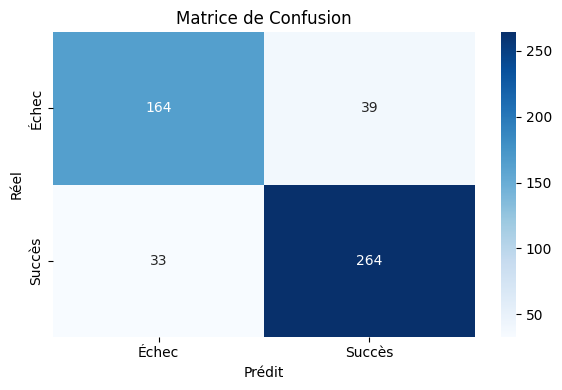

In [7]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Échec', 'Succès'], yticklabels=['Échec', 'Succès'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.tight_layout()
plt.show()

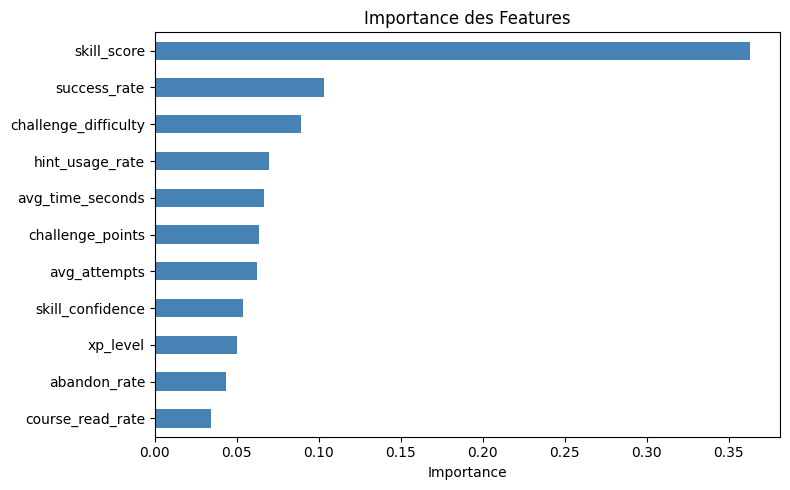

In [8]:
# Feature Importance
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='steelblue')
plt.title('Importance des Features')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Étape 5 : Export du modèle

In [9]:
# Sauvegarder le modèle
MODEL_PATH = '../models/xgb_recommender.pkl'
import os
joblib.dump(model, MODEL_PATH)
print(f'✅ Modèle sauvegardé : {MODEL_PATH}')
print(f'   Taille : {os.path.getsize(MODEL_PATH) / 1024:.1f} KB')

✅ Modèle sauvegardé : ../models/xgb_recommender.pkl


NameError: name 'os' is not defined

## Étape 6 : Test rapide (simuler une recommandation)

In [ ]:
import os
import joblib
import pandas as pd
MODEL_PATH = '../models/xgb_recommender.pkl'
# Charger le modèle sauvegardé
loaded_model = joblib.load(MODEL_PATH)

# Simuler un learner débutant face à un challenge intermédiaire
test_learner = pd.DataFrame([{
    'success_rate': 0.45,
    'avg_attempts': 3.5,
    'avg_time_seconds': 600,
    'hint_usage_rate': 0.4,
    'course_read_rate': 0.7,
    'abandon_rate': 0.15,
    'skill_score': 0.35,
    'skill_confidence': 0.6,
    'challenge_difficulty': 2,  # intermediate
    'challenge_points': 120,
    'xp_level': 3
}])

proba = loaded_model.predict_proba(test_learner)[0][1]
print(f'Probabilité de succès : {proba:.2%}')
print(f'Dans la zone de flow (50-85%) ? {"✅ OUI" if 0.50 <= proba <= 0.85 else "❌ NON"}')

In [ ]:
conn.close()
print('Connexion fermée.')